In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [11]:
df = pd.read_csv('marketing_email_response_logreg.csv')
target_col = "responded"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Shape: (300, 3)
Target distribution:
 responded
1    150
0    150
Name: count, dtype: int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000))
])

In [14]:
param_grid = {
    "logreg__C": [0.01, 0.1, 1, 5, 10],
    "logreg__class_weight": [None, "balanced"],
    "logreg__solver": ["lbfgs", "liblinear"],
    "logreg__penalty": ["l2"],  # keep it simple
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best CV Accuracy:", grid.best_score_)
print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_


Best CV Accuracy: 0.7416666666666666
Best Params: {'logreg__C': 0.01, 'logreg__class_weight': None, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}


In [15]:
y_pred_default = best_model.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)
print("\nTest Accuracy (threshold=0.5):", acc_default)

print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, y_pred_default))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))


Test Accuracy (threshold=0.5): 0.7

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.75      0.60      0.67        30
           1       0.67      0.80      0.73        30

    accuracy                           0.70        60
   macro avg       0.71      0.70      0.70        60
weighted avg       0.71      0.70      0.70        60

Confusion Matrix:
[[18 12]
 [ 6 24]]


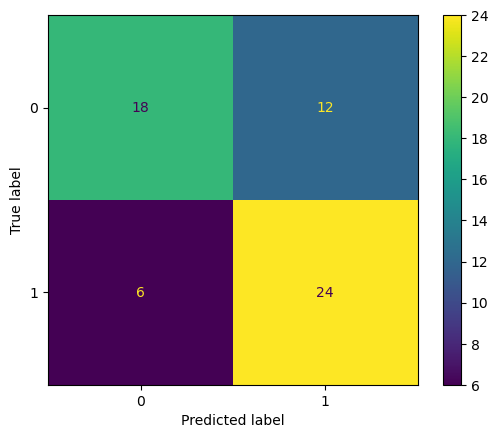

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_default)
plt.show()
